#Шаг 1. Импорты

In [ ]:
# Матрица ошибок показывает, какие классы модель путает
# Macro F1-score — качество по всем классам отдельно
# Accuracy — доля правильных ответов
# Считаем веса классов для борьбы с дисбалансом
# Нормализуем данные для стабильного обучения нейросети
# Делим данные на train / validation / test

# ============================================
# ИМПОРТ БИБЛИОТЕК
# ============================================
# pandas — работа с таблицами и CSV
# numpy — работа с массивами и числами
# matplotlib — построение графиков
# sklearn — предобработка, метрики, разделение данных
# tensorflow/keras — создание и обучение нейронной сети

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models

#Шаг 2. Загрузка данных

In [ ]:
# Загружаем CSV-файл с ЭКГ-сигналами
df = pd.read_csv("dataset/task2_1-ecg5000-heartbeat-classification.csv")

print(df.head())
print(df.shape)
print(df["label_name"].value_counts())

  source_split  label_id label_name     t_000     t_001     t_002     t_003  \
0        train         1          N -0.112522 -2.827204 -3.773897 -4.349751   
1        train         1          N -1.100878 -3.996840 -4.285843 -4.506579   
2        train         1          N -0.567088 -2.593450 -3.874230 -4.584095   
3        train         1          N  0.490473 -1.914407 -3.616364 -4.318823   
4        train         1          N  0.800232 -0.874252 -2.384761 -3.973292   

      t_004     t_005     t_006  ...     t_130     t_131     t_132     t_133  \
0 -4.376041 -3.474986 -2.181408  ...  0.160348  0.792168  0.933541  0.796958   
1 -4.022377 -3.234368 -1.566126  ...  0.560327  0.538356  0.656881  0.787490   
2 -4.187449 -3.151462 -1.742940  ...  1.284825  0.886073  0.531452  0.311377   
3 -4.268016 -3.881110 -2.993280  ...  0.491173  0.350816  0.499111  0.600345   
4 -4.338224 -3.802422 -2.534510  ...  0.966606  1.148884  0.958434  1.059025   

      t_134     t_135     t_136     t_137   

#Шаг 3. Разделяем признаки и метки

In [ ]:
signal_columns = [col for col in df.columns if col.startswith("t_")]

X = df[signal_columns].values
y = df["label_name"].values

print(X.shape)
print(y[:10])

(5000, 140)
['N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N']


#Шаг 4. Кодируем классы

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)
print(y_encoded[:10])

['N' 'PVC' 'R-on-T PVC' 'SP or EB' 'UB']
[0 0 0 0 0 0 0 0 0 0]


#Шаг 5. Train / Validation / Test

In [ ]:
# Делим данные на train / validation / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(3500, 140)
(750, 140)
(750, 140)


#Шаг 6. Нормализация

In [ ]:
# Нормализуем данные для стабильного обучения нейросети
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#Шаг 7. Меняем форму для RNN

In [ ]:
# Преобразуем данные в формат (batch, time_steps, features)
X_train = X_train.reshape(X_train.shape[0], 140, 1)
X_val = X_val.reshape(X_val.shape[0], 140, 1)
X_test = X_test.reshape(X_test.shape[0], 140, 1)

print(X_train.shape)

(3500, 140, 1)


#Шаг 8. Учитываем дисбаланс классов

In [ ]:
# Считаем веса классов для борьбы с дисбалансом
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{np.int64(0): np.float64(0.34263338228095935), np.int64(1): np.float64(10.447761194029852), np.int64(2): np.float64(0.5658852061438965), np.int64(3): np.float64(5.147058823529412), np.int64(4): np.float64(41.1764705882353)}


#Шаг 9. Создаём модель

In [ ]:
# Настраиваем оптимизатор, функцию ошибки и метрики
# Dropout помогает бороться с переобучением
# GRU анализирует временную последовательность признаков
# MaxPooling уменьшает размер последовательности и оставляет важные признаки
# BatchNormalization стабилизирует распределение признаков
# Conv1D ищет локальные формы ЭКГ: пики, спады, QRS-комплексы
num_classes = len(label_encoder.classes_)

model = models.Sequential([
    layers.Input(shape=(140, 1)),

    layers.Conv1D(32, kernel_size=5, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.Conv1D(64, kernel_size=5, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),

    layers.GRU(64),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 140, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 140, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 70, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 70, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 70, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 35, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,325 (157.52 KB)

 Trainable params: 40,133 (156.77 KB)

 Non-trainable params: 192 (768.00 B)

#Шаг 10. Обучение

In [ ]:
# EarlyStopping останавливает обучение при переобучении
# Запускаем обучение модели
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6920 - loss: 1.2399 - val_accuracy: 0.7427 - val_loss: 1.1100
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7714 - loss: 1.0628 - val_accuracy: 0.7493 - val_loss: 0.9014
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8051 - loss: 0.9218 - val_accuracy: 0.6800 - val_loss: 0.8346
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7657 - loss: 0.8688 - val_accuracy: 0.8680 - val_loss: 0.4959
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8271 - loss: 0.8042 - val_accuracy: 0.7840 - val_loss: 0.6655
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8271 - loss: 0.7066 - val_accuracy: 0.9040 - val_loss: 0.3704
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8580 - loss: 0.6501 - val_accuracy: 0.8933 - val_loss: 0.3638
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8531 - loss: 0.6445 - val_accu

#Шаг 11. График обучения

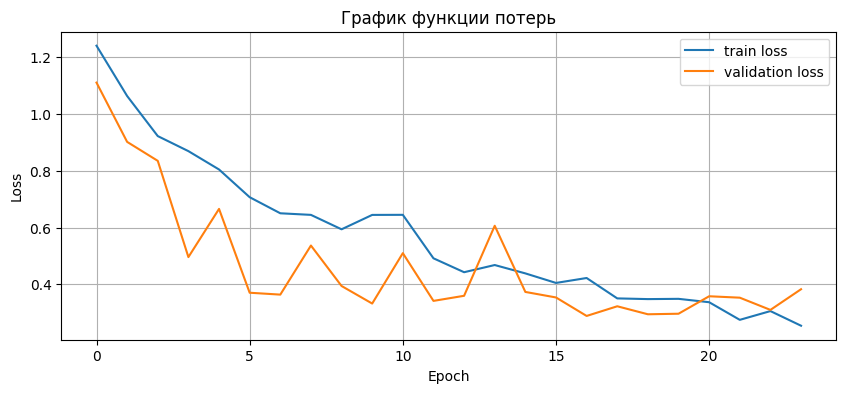

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("График функции потерь")
plt.legend()
plt.grid()
plt.show()

#Шаг 12. Оценка на тесте

In [ ]:
# Macro F1-score — качество по всем классам отдельно
# Accuracy — доля правильных ответов
# Получаем предсказания модели
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", accuracy)
print("Macro F1-score:", macro_f1)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Accuracy: 0.912
Macro F1-score: 0.5790821482558749


#Шаг 13. Матрица ошибок

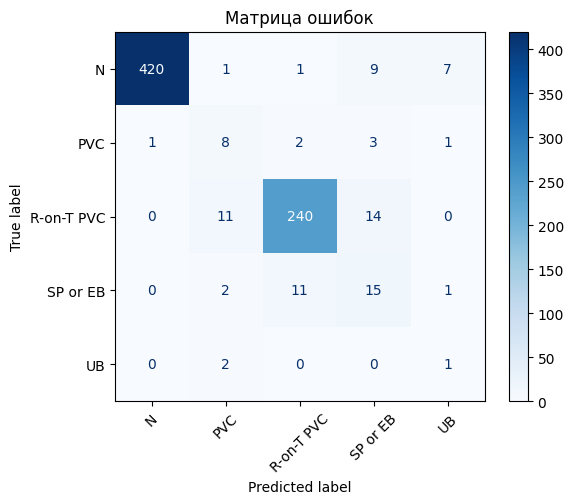

In [ ]:
# Матрица ошибок показывает, какие классы модель путает
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Матрица ошибок")
plt.show()

#Шаг 14. Несколько примеров ЭКГ

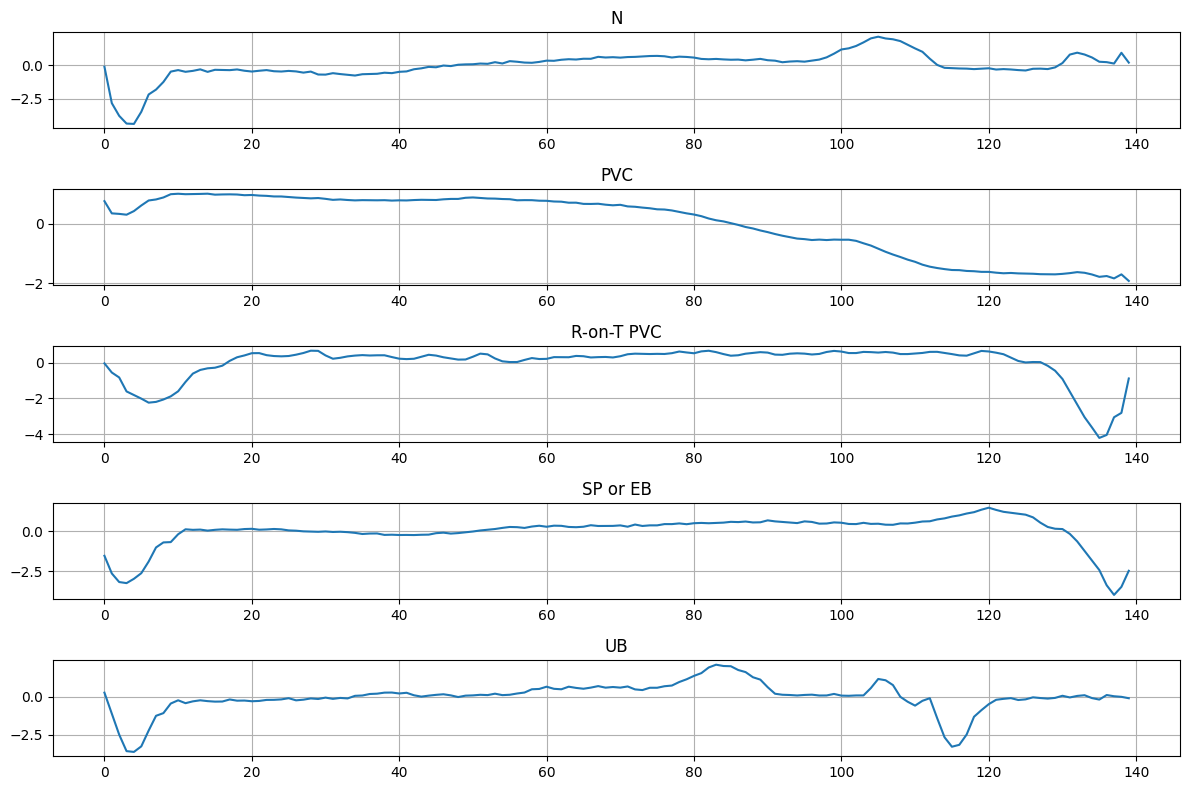

In [ ]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(label_encoder.classes_):
    class_id = label_encoder.transform([class_name])[0]
    index = np.where(y_encoded == class_id)[0][0]

    plt.subplot(len(label_encoder.classes_), 1, i + 1)
    plt.plot(X[index])
    plt.title(class_name)
    plt.grid()

plt.tight_layout()
plt.show()

<h1>Отчёт</h1>

Для предобработки ЭКГ использовалась нормализация признаков, так как значения сигнала имеют разный масштаб, а нейронная сеть стабильнее обучается на нормализованных данных. Данные были разделены на train, validation и test с сохранением баланса классов через stratify. Для борьбы с дисбалансом классов использовались class_weight, чтобы редкие классы сильнее учитывались при обучении.

Модель построена как гибрид Conv1D + GRU. Conv1D выделяет локальные признаки формы ЭКГ: пики, спады и участки комплекса QRS. GRU анализирует последовательность этих признаков во времени. Для контроля переобучения использовались EarlyStopping и ReduceLROnPlateau.

Качество оценивалось с помощью Accuracy, macro F1-score и матрицы ошибок. Чаще всего модель может путать редкие патологические классы между собой, потому что их меньше в выборке, а форма некоторых сокращений похожа. Нормальный класс N обычно распознаётся лучше, так как он представлен большим числом примеров.

In [ ]:
from sklearn.metrics import classification_report

# Названия классов
class_names = label_encoder.classes_

# Подробный отчёт по каждому классу
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).T

print(report_df)

              precision    recall  f1-score  support
N              0.997625  0.958904  0.977881  438.000
PVC            0.333333  0.533333  0.410256   15.000
R-on-T PVC     0.944882  0.905660  0.924855  265.000
SP or EB       0.365854  0.517241  0.428571   29.000
UB             0.100000  0.333333  0.153846    3.000
accuracy       0.912000  0.912000  0.912000    0.912
macro avg      0.548339  0.649695  0.579082  750.000
weighted avg   0.937684  0.912000  0.923257  750.000


In [ ]:
# Оставляем только реальные классы, без accuracy/macro avg/weighted avg
class_report = report_df.loc[class_names]

# Лучший и худший классы по F1-score
best_class = class_report["f1-score"].idxmax()
worst_class = class_report["f1-score"].idxmin()

print("Лучше всего модель распознаёт класс:", best_class)
print("F1-score:", class_report.loc[best_class, "f1-score"])

print("Хуже всего модель распознаёт класс:", worst_class)
print("F1-score:", class_report.loc[worst_class, "f1-score"])

Лучше всего модель распознаёт класс: N
F1-score: 0.9778812572759022
Хуже всего модель распознаёт класс: UB
F1-score: 0.15384615384615385


In [ ]:
# Матрица ошибок показывает, какие классы модель путает
cm = confusion_matrix(y_test, y_pred)

for i, class_name in enumerate(class_names):
    correct = cm[i, i]
    total = cm[i].sum()
    mistakes = total - correct

    print(f"\nКласс {class_name}:")
    print(f"Всего объектов: {total}")
    print(f"Правильно распознано: {correct}")
    print(f"Ошибок: {mistakes}")

    if mistakes > 0:
        confused_with = np.argmax(np.where(np.arange(len(class_names)) == i, -1, cm[i]))
        print(f"Чаще всего путается с классом: {class_names[confused_with]}")


Класс N:
Всего объектов: 438
Правильно распознано: 420
Ошибок: 18
Чаще всего путается с классом: SP or EB

Класс PVC:
Всего объектов: 15
Правильно распознано: 8
Ошибок: 7
Чаще всего путается с классом: SP or EB

Класс R-on-T PVC:
Всего объектов: 265
Правильно распознано: 240
Ошибок: 25
Чаще всего путается с классом: SP or EB

Класс SP or EB:
Всего объектов: 29
Правильно распознано: 15
Ошибок: 14
Чаще всего путается с классом: R-on-T PVC

Класс UB:
Всего объектов: 3
Правильно распознано: 1
Ошибок: 2
Чаще всего путается с классом: PVC


Лучше всего модель распознаёт класс N, так как нормальные сердечные сокращения представлены в датасете большим количеством примеров и имеют более устойчивую форму сигнала. Хуже модель может распознавать редкие патологические классы, например R-on-T PVC, SP or EB или UB. Это связано с дисбалансом классов и похожей морфологией отдельных аномальных сокращений. Анализ матрицы ошибок показывает, с какими именно классами модель чаще всего путает каждый тип сердечного сокращения.